<a href="https://colab.research.google.com/github/ariyan378/Machine-Learning-Projects/blob/main/Loan_Prediction_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as  sns
import plotly.express as px
%matplotlib inline
sns.set_style('darkgrid')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler


# **Data Exploration**

In [116]:
import pandas as pd

# Raw link to the CSV file
url = "https://raw.githubusercontent.com/ariyan378/Machine-Learning-Projects/main/loan_prediction_dataset.csv"


df = pd.read_csv(url)


df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


In [118]:
df.columns.tolist()

['Age',
 'Income',
 'Credit_Score',
 'Loan_Amount',
 'Loan_Term',
 'Employment_Status',
 'Loan_Approved']

In [119]:
df.dtypes

,0
Age,int64
Income,int64
Credit_Score,int64
Loan_Amount,int64
Loan_Term,int64
Employment_Status,object
Loan_Approved,int64


In [120]:
df.describe()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,0.000000
max,69.000000,149992.000000,849.000000,49994.000000,60.00000,1.000000


In [121]:
df.isna().sum()

,0
Age,0
Income,0
Credit_Score,0
Loan_Amount,0
Loan_Term,0
Employment_Status,0
Loan_Approved,0


In [122]:
df.duplicated().sum()

np.int64(0)

# **Univariate analysis**

**age**

In [123]:
df.head(3)

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0


In [124]:

fig = px.histogram(df,
                   x='Age',
                   marginal='box',
                   nbins=51,
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

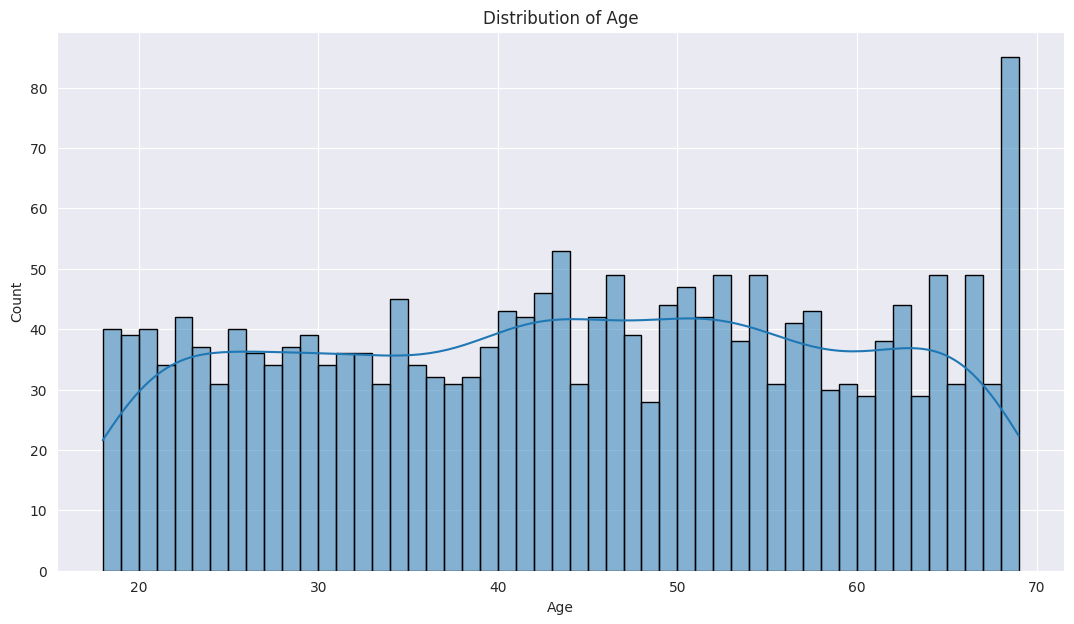

In [125]:
plt.figure(figsize=(13,7))
sns.histplot(data=df, x='Age', bins=51, edgecolor='black', linewidth=1 , kde=True)
plt.title("Distribution of Age")
plt.show()

In [126]:
print(df['Age'].skew())
print(df['Age'].kurtosis())

-0.04072721181461678
-1.1563745014058573


Data Distribution Following close to Uniform distribution but age of 69 people taking more loan.

**Income**

In [127]:
fig = px.histogram(df , x=df['Income'] , marginal='box', nbins=30, title='Distribution of Income')

fig.update_layout(bargap=0.1)
fig.show()

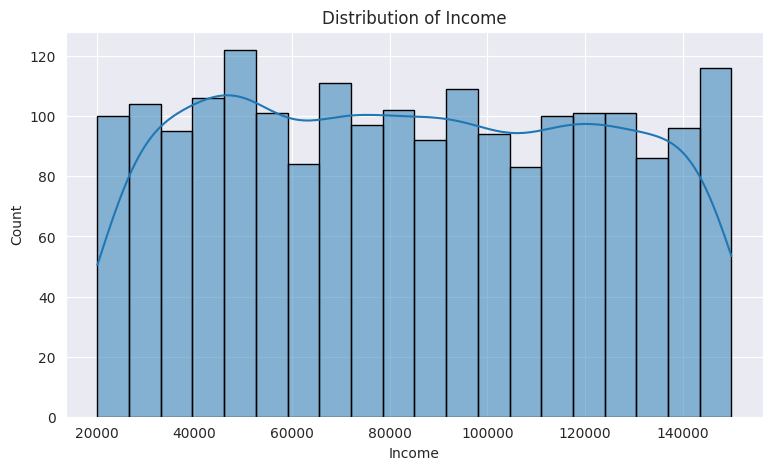

In [128]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x=df['Income'], bins=20, edgecolor='black', linewidth=1 , kde=True)
plt.title("Distribution of Income")
plt.show()

Data Distribution Following Uniform distribution

**Credit Score**

In [129]:
df.head(3)

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0


In [130]:
fig = px.histogram(df , x=df['Credit_Score'] , marginal='box', nbins=20, title='Distribution of Credit Score')



fig.update_layout(bargap=0.1)
fig.show()

Data following Uniform Distribution

**Loan_Amount**

In [131]:
df.head(2)

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1


In [132]:
fig = px.histogram(df , x=df['Loan_Amount'] , marginal='box', nbins=30, title='Distribution of Loan Amount')

fig.update_layout(bargap=0.1)
fig.show()

Uniform Distribution

**Loan Term**

In [133]:
df.head(6)

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0
5,25,64859,600,31005,36,Employed,0


In [134]:
fig = px.histogram(df , x=df['Loan_Term'] , marginal='box', nbins=5, title='Distribution of Loan term')

fig.update_layout(bargap=0.1)
fig.show()

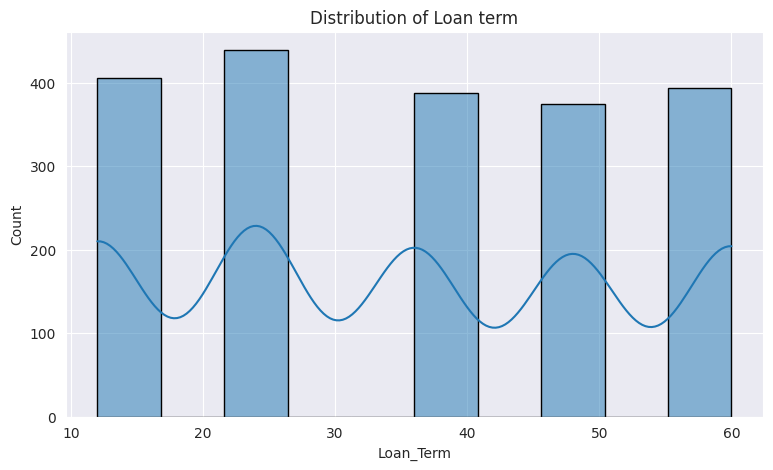

In [135]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x=df['Loan_Term'], bins=10, edgecolor='black', linewidth=1 , kde=True)
plt.title("Distribution of Loan term")
plt.show()

**Employment Status**

In [136]:
df.head(3)

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0


/tmp/ipykernel_2478/2005197440.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




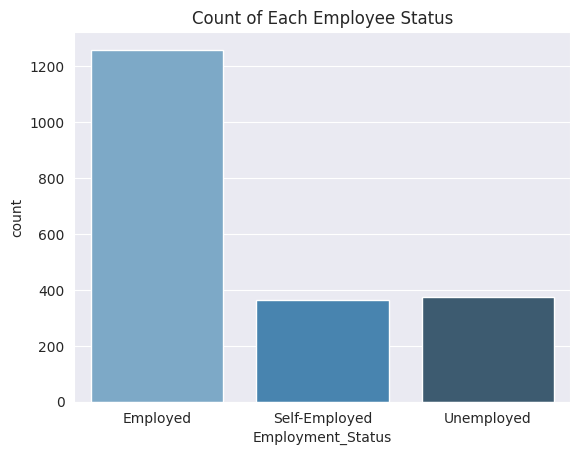

In [137]:
sns.countplot(data=df, x=df['Employment_Status'], palette='Blues_d' )
plt.title('Count of Each Employee Status')
plt.show()

It is a  categorical and has three unique value.we will use one hot encoding for this

**Bivariate Analysis**

In [138]:
# Age and Loan Amount
px.scatter(df , x=df['Age'], y=df['Loan_Amount'] , title='Relation Between Age and Loan amount')

In [139]:
df['Age'].corr(df['Loan_Amount'])

np.float64(-0.009202672872903224)

There is no correlation between them

In [140]:
# Age and Income
px.scatter(df , x=df['Age'], y=df['Income'] , title='Relation Between Age and Income')

In [141]:
df['Age'].corr(df['Income'])

np.float64(0.021819942909346555)

There is No Correlation

In [142]:
# Age and Income
px.scatter(df , x=df['Income'], y=df['Loan_Amount'] , title='Relation Between Loan and Income')

In [143]:
#  Income and Loan Amount
px.scatter(df , x=df['Income'], y=df['Loan_Amount'] , title='Relation Between Age and Income')

**Multivariate Analysis**

In [145]:
df.head(3)

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0


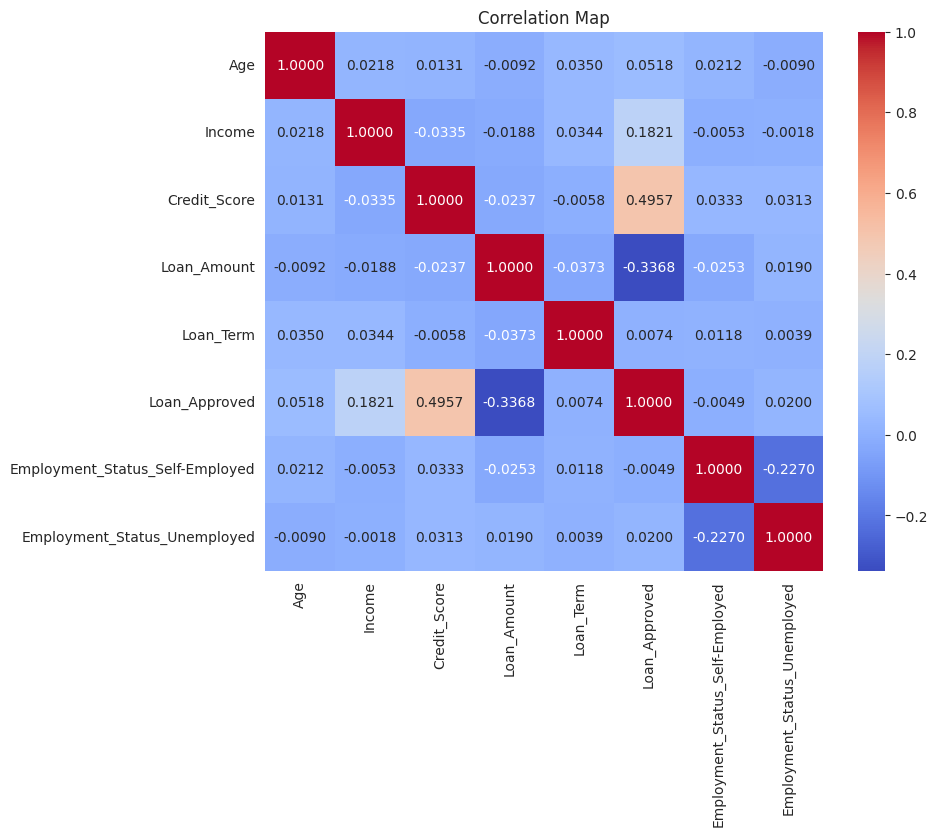

In [160]:
plt.figure(figsize=(9,7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr , annot=True , fmt='.4f',cmap='coolwarm' , cbar=True)
plt.title("Correlation Map")
plt.show()

**Encoding**

In [157]:
df['Employment_Status'].unique()

array(['Employed', 'Self-Employed', 'Unemployed'], dtype=object)

In [158]:
df = pd.read_csv(url)

nominal_cols = ['Employment_Status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved,Employment_Status_Self-Employed,Employment_Status_Unemployed
0,56,81788,334,15022,48,0,0,0
1,69,102879,781,21013,24,1,1,0
2,46,58827,779,39687,60,0,1,0
3,32,127188,364,16886,24,0,0,1
4,60,25655,307,26256,36,0,0,1


In [163]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns='Loan_Approved')
y = df['Loan_Approved']
rf_selector = RandomForestClassifier(n_estimators=200,
random_state=42)
rf_selector.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_selector.feature_importances_
}).sort_values(by='importance', ascending=False)
importance_df.head(4)

,feature,importance
2,Credit_Score,0.489163
3,Loan_Amount,0.296419
1,Income,0.180643
0,Age,0.022424


# **Model Run And Evaluation**

In [168]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining class distribution:\n",
y_train.value_counts(normalize=True))
print("\nTesting class distribution:\n",
y_test.value_counts(normalize=True))

Training set shape: (1600, 7)
Testing set shape: (400, 7)

Training class distribution:
 Loan_Approved
0    0.82875
1    0.17125
Name: proportion, dtype: float64

Testing class distribution:
 Loan_Approved
0    0.83
1    0.17
Name: proportion, dtype: float64


In [171]:


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")

y_pred_log = log_reg.predict(X_test_scaled)
print("\nLogistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_log, target_names=['Not Approved', 'Approved']))


Logistic Regression trained.

Logistic Regression Performance
Accuracy: 0.915

Classification Report:

              precision    recall  f1-score   support

Not Approved       0.94      0.95      0.95       332
    Approved       0.77      0.72      0.74        68

    accuracy                           0.92       400
   macro avg       0.85      0.84      0.85       400
weighted avg       0.91      0.92      0.91       400

